# B3 — CVaR-Constrained PPO (Core Thesis Contribution)

**Purpose:** Calibrate the CVaR drawdown threshold from B1 rollouts on training data;
train B3 warm-started from the best B2 model; evaluate on the test set.

**CMDP formulation:**
```
max_θ  E[Σ γᵗ rₜ]      (base reward = CjMmCriterion, identical to B1)
s.t.   CVaR_α(MaxDrawdown) ≤ d
```

**Lagrangian relaxation:**
```
max_θ min_λ  J(θ) − λ · (CVaR_α(DD) − d)
```

**Key design choices:**
- Threshold `d` calibrated from B1 agent rollouts on **training days only** (no test leakage).
- Warm-start from best B2 weights so early rollouts are already near-feasible.
- VecNormalize wraps the `DrawdownCostWrapper` (outer layer) to normalise observations.
- `CVaRLagrangianCallback` holds a direct reference to the `DrawdownCostWrapper` to read `step_costs`.

**Env stack:**
```
VecNormalize
  └── DrawdownCostWrapper
        └── StableBaselinesTradingEnvironment
              └── TradingEnvironment
```

**Outputs:**
- `models/ppo_b3_doge.zip`, `models/vecnorm_b3.pkl`
- `results/b3_test_results.csv`, `results/cvar_threshold_d.txt`

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    (p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
     if (p / "procs").exists()),
    pathlib.Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize

from procs.gym.experiment_config import ReplayExperimentConfig
from procs.gym.data_loader import load_multi_day
from procs.gym.sb3_wrapper import StableBaselinesTradingEnvironment
from procs.gym.notebook_support import (
    build_multi_day_replay_env,
    calibrate_cvar_threshold_sampled_windows,
    make_vecnorm,
    evaluate_rl_per_day,
)
from procs.rewards import CjMmCriterion
from procs.gym.cvar_lagrangian import (
    DrawdownCostWrapper,
    CVaRLagrangianCallback,
)
from procs.gym.helpers.plotting import plot_cvar_training

cfg = ReplayExperimentConfig()
cfg.ensure_artifact_dirs()
print(f"Repo root : {cfg.repo_root}")

Repo root : C:\Users\john-\Documents\Thesis_AI4T


## Section 1 — Data Loading and Train/Test Split

In [2]:
TRAIN_DAYS = 6

daily_S, daily_dt, dates = load_multi_day(str(cfg.datasets_dir), pair=cfg.pair)

train_S     = daily_S[:TRAIN_DAYS]
train_dt    = daily_dt[:TRAIN_DAYS]
train_dates = dates[:TRAIN_DAYS]

test_S      = daily_S[TRAIN_DAYS:]
test_dt     = daily_dt[TRAIN_DAYS:]
test_dates  = dates[TRAIN_DAYS:]


EXPECTED_TEST_DAYS = 23
if len(train_S) != TRAIN_DAYS or len(test_S) != EXPECTED_TEST_DAYS:
    raise ValueError(
        f"Expected {TRAIN_DAYS} train days and {EXPECTED_TEST_DAYS} test days, "
        f"found {len(train_S)} and {len(test_S)}."
    )
if set(map(str, train_dates)) & set(map(str, test_dates)):
    raise ValueError("Train/test date overlap detected.")

train_snapshots = sum(len(S) for S in train_S)

print(f"Training: {len(train_S)} separate days, {train_snapshots:,} total snapshots")
print(f"Test    : {len(test_S)} days ({test_dates[0]} → {test_dates[-1]})")

  2025-01-01:  713,815 snapshots, σ=0.000021
  2025-01-02:  766,464 snapshots, σ=0.000035
  2025-01-03:  776,383 snapshots, σ=0.000047
  2025-01-04:  778,293 snapshots, σ=0.000045
  2025-01-05:  723,494 snapshots, σ=0.000031
  2025-01-06:  766,311 snapshots, σ=0.000035
  2025-01-07:  787,093 snapshots, σ=0.000062
  2025-01-08:  821,589 snapshots, σ=0.000052
  2025-01-09:  809,421 snapshots, σ=0.000046
  2025-01-10:  789,320 snapshots, σ=0.000045
  2025-01-11:  724,826 snapshots, σ=0.000023
  2025-01-12:  719,550 snapshots, σ=0.000022
  2025-01-13:  819,981 snapshots, σ=0.000046
  2025-01-14:  775,454 snapshots, σ=0.000038
  2025-01-15:  782,299 snapshots, σ=0.000047
  2025-01-16:  788,946 snapshots, σ=0.000048
  2025-01-17:  801,259 snapshots, σ=0.000061
  2025-01-18:  829,125 snapshots, σ=0.000074
  2025-01-19:  842,892 snapshots, σ=0.000096
  2025-01-20:  857,508 snapshots, σ=0.000115
  2025-01-21:  848,107 snapshots, σ=0.000112
  2025-01-22:  812,180 snapshots, σ=0.000044
  2025-01-

## Section 2 — Load B1 and B2 Best Models

In [3]:
# Load B1 (unconstrained PPO) for CVaR threshold calibration
model_b1 = PPO.load(str(cfg.model_path("ppo_b1_doge")), device="cpu")
print(f"Loaded B1: {cfg.model_path('ppo_b1_doge')}.zip")

# Load best B2 alpha for warm-start
best_alpha_path = cfg.result_path("b2_best_alpha.txt")
with open(best_alpha_path) as f:
    best_alpha = float(f.read().strip())
print(f"Best B2 α = {best_alpha}  (from {best_alpha_path})")

model_b2_best = PPO.load(str(cfg.model_path(f"ppo_b2_alpha{best_alpha}_doge")), device="cpu")
print(f"Loaded B2 best: ppo_b2_alpha{best_alpha}_doge.zip")

Loaded B1: C:\Users\john-\Documents\Thesis_AI4T\models\ppo_b1_doge.zip
Best B2 α = 1.0  (from C:\Users\john-\Documents\Thesis_AI4T\results\b2_best_alpha.txt)
Loaded B2 best: ppo_b2_alpha1.0_doge.zip


## Section 3 — CVaR Threshold Calibration

The threshold `d` is calibrated from the B1 agent's drawdown on **training days only**.
Using windowed calibration (`n_steps=2048`) matches the window size used in training.

`d = CVaR_{0.2}(MaxDD_{B1, window}) × (1 − 0.2)`

**Critical:** No test-day data is used here.

In [4]:
# Sample PPO-length windows across all training days for B3 threshold calibration.
# This keeps the threshold training-only without reintroducing artificial day joins.
print("Calibrating CVaR threshold from B1 rollouts on sampled training windows ...")
d, cvar_uc = calibrate_cvar_threshold_sampled_windows(
    daily_midprices=train_S,
    daily_dt_arrays=train_dt,
    model=model_b1,
    vecnorm_path=cfg.vecnorm_path("vecnorm_b1"),
    config=cfg,
    n_steps=cfg.ppo_n_steps,
    cvar_alpha=0.2,
    n_windows=50,
    tighten=0.2,
    seed=cfg.evaluation_seed,
    verbose=True,
)

print(f"\nCVaR threshold d = {d:.6f}  (raw CVaR = {cvar_uc:.6f})")

thresh_path = cfg.result_path("cvar_threshold_d.txt")
with open(thresh_path, "w") as f:
    f.write(f"{d}\n{cvar_uc}\n")
print(f"Saved -> {thresh_path}")


Calibrating CVaR threshold from B1 rollouts on sampled training windows ...
CVaR threshold calibration (sampled windows, window=2048 steps)
  Training days used: 6
  Windows sampled: 50
  CVaR_20% = mean of worst 10 = 0.000834
  Tighten 20% -> d = 0.000667
  [mean=0.000464  median=0.000430  p95=0.000848]

CVaR threshold d = 0.000667  (raw CVaR = 0.000834)
Saved -> C:\Users\john-\Documents\Thesis_AI4T\results\cvar_threshold_d.txt


## Section 4 — B3 Training

Env stack: `VecNormalize(DrawdownCostWrapper(StableBaselinesTradingEnvironment(env)))`

- `DrawdownCostWrapper` reads `self.env.env.model_dynamics.state` (i.e., the raw `TradingEnvironment`) — this is why VecNormalize wraps the outside, not inside.
- The callback holds a direct reference to `cost_wrapper` to access `step_costs` regardless of wrapping.
- Warm-started from B2 best weights via `set_parameters()`.

**`TOTAL_TIMESTEPS` guide:**
- Quick local test: `200_000`
- Full Snellius: `max(2 * len(S_train), 2_000_000)`

In [5]:
TOTAL_TIMESTEPS = max(train_snapshots, 1_000_000)
CVAR_ALPHA  = 0.2
LR_LAMBDA   = 0.01
LAMBDA_MAX  = 500.0

print(f"CVaR threshold d  = {d:.6f}")
print(f"α (tail prob)     = {CVAR_ALPHA}")
print(f"λ learning rate   = {LR_LAMBDA}")
print(f"λ max             = {LAMBDA_MAX}")
print(f"Total timesteps   = {TOTAL_TIMESTEPS:,}")

# Build training env for B3
train_env_b3 = build_multi_day_replay_env(
    train_S, train_dt, cfg,
    reward_fn=CjMmCriterion(per_step_inventory_aversion=cfg.phi),
    mode="sequential",
)
train_sb3_b3   = StableBaselinesTradingEnvironment(train_env_b3)
cost_wrapper   = DrawdownCostWrapper(train_sb3_b3)
train_vn_b3    = make_vecnorm(cost_wrapper, cfg, training=True, norm_reward=False)

cvar_callback = CVaRLagrangianCallback(
    cost_wrapper=cost_wrapper,
    cvar_alpha=CVAR_ALPHA,
    dd_threshold=d,
    lr_lambda=LR_LAMBDA,
    lambda_max=LAMBDA_MAX,
    verbose=1,
)

model_b3 = PPO(
    "MlpPolicy",
    train_vn_b3,
    **cfg.ppo_kwargs(),
    tensorboard_log=str(cfg.repo_root / "tb_logs" / "b3"),
    verbose=1,
    device="cpu",
)

# Warm-start from B2 best — critical for feasible early rollouts (Bug 6 fix)
model_b3.set_parameters(model_b2_best.get_parameters())
print("B3 warm-started from B2 best weights.")

model_b3.learn(total_timesteps=TOTAL_TIMESTEPS, callback=cvar_callback)

CVaR threshold d  = 0.000667
α (tail prob)     = 0.2
λ learning rate   = 0.01
λ max             = 500.0
Total timesteps   = 4,524,760
Using cpu device
B3 warm-started from B2 best weights.
Logging to C:\Users\john-\Documents\Thesis_AI4T\tb_logs\b3\PPO_1
  CVaR=0.000030  d=0.000667  viol=-0.9551  λ=0.0000
-----------------------------
| time/              |      |
|    fps             | 2097 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
  CVaR=0.000000  d=0.000667  viol=-1.0000  λ=0.0000
------------------------------------------
| time/                   |              |
|    fps                  | 1916         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0023942345 |
|    clip_fraction        | 0.00532      |
|    clip_range           | 0.2          |
| 

In [6]:
model_b3.save(str(cfg.model_path("ppo_b3_doge")))
train_vn_b3.save(str(cfg.vecnorm_path("vecnorm_b3")))
print(f"Saved model   → {cfg.model_path('ppo_b3_doge')}.zip")
print(f"Saved vecnorm → {cfg.vecnorm_path('vecnorm_b3')}")

Saved model   → C:\Users\john-\Documents\Thesis_AI4T\models\ppo_b3_doge.zip
Saved vecnorm → C:\Users\john-\Documents\Thesis_AI4T\models\vecnorm_b3.pkl


## Section 5 — λ Convergence Diagnostics

Healthy convergence: λ rises from 0, stabilises at a non-zero value well below `lambda_max`.
- λ → 0: constraint not active (threshold too loose)
- λ → λ_max: constraint too tight or training CVaR still above threshold

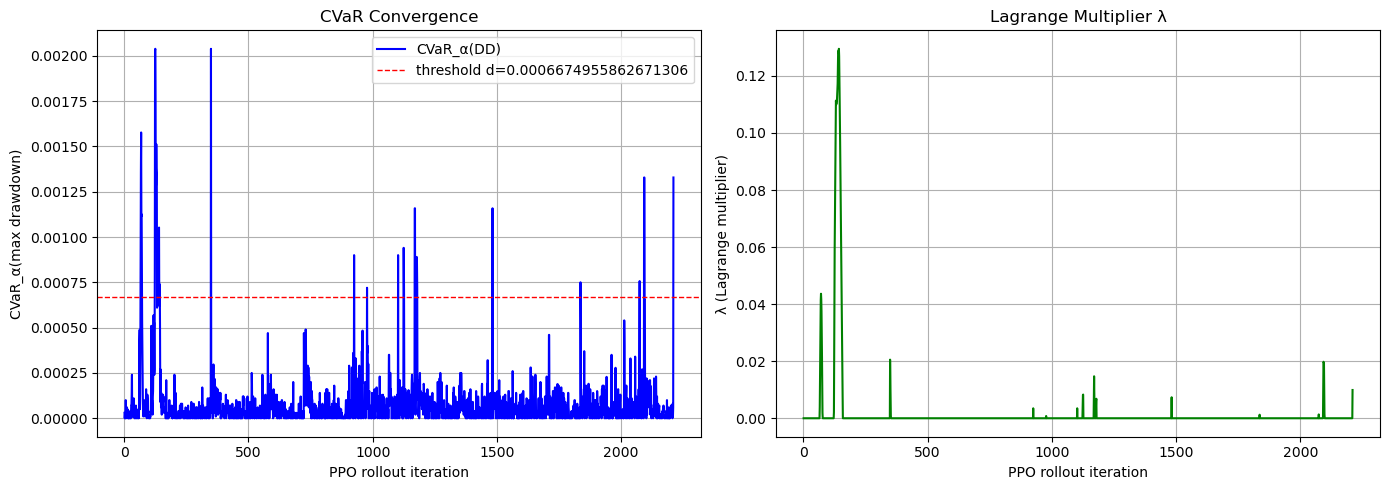

Final λ = 0.0099  (λ_max=500.0, OK)
Final CVaR = 0.001328  (threshold d=0.000667)


In [7]:
if cvar_callback.lambda_history and cvar_callback.cvar_history:
    try:
        plot_cvar_training(
            cvar_history=cvar_callback.cvar_history,
            lambda_history=cvar_callback.lambda_history,
            dd_threshold=d,
        )
    except Exception:
        # Fallback manual plot if plot_cvar_training API differs
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        rollouts = range(len(cvar_callback.lambda_history))

        axes[0].plot(rollouts, cvar_callback.cvar_history, label=f"CVaR_{CVAR_ALPHA}")
        axes[0].axhline(d, color="crimson", linestyle="--", label=f"threshold d={d:.4f}")
        axes[0].set_title("Training CVaR(MaxDD)")
        axes[0].set_xlabel("Rollout")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(rollouts, cvar_callback.lambda_history, color="darkorange", label="λ")
        axes[1].axhline(LAMBDA_MAX, color="gray", linestyle=":", alpha=0.7, label=f"λ_max={LAMBDA_MAX}")
        axes[1].set_title("Lagrange Multiplier λ")
        axes[1].set_xlabel("Rollout")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.suptitle("B3 CVaR Lagrangian — Training Convergence", fontsize=13)
        plt.tight_layout()
        plt.savefig(str(cfg.result_path("b3_lambda_convergence.png")), dpi=150, bbox_inches="tight")
        plt.show()

    print(f"Final λ = {cvar_callback.lambda_history[-1]:.4f}  "
          f"(λ_max={LAMBDA_MAX}, {'OK' if cvar_callback.lambda_history[-1] < LAMBDA_MAX else 'AT CAP'})")
    print(f"Final CVaR = {cvar_callback.cvar_history[-1]:.6f}  (threshold d={d:.6f})")
else:
    print("No callback history recorded — check TOTAL_TIMESTEPS > ppo_n_steps.")

In [8]:
# Save callback history for nb4
import json
history_path = cfg.result_path("b3_callback_history.json")
with open(history_path, "w") as f:
    json.dump({
        "lambda_history": cvar_callback.lambda_history,
        "cvar_history":   cvar_callback.cvar_history,
        "dd_threshold":   d,
        "lambda_max":     LAMBDA_MAX,
        "cvar_alpha":     CVAR_ALPHA,
    }, f)
print(f"Saved callback history → {history_path}")

Saved callback history → C:\Users\john-\Documents\Thesis_AI4T\results\b3_callback_history.json


## Section 6 — Test Evaluation (Days 7–29)

In [10]:
model_b3_loaded = PPO.load(str(cfg.model_path("ppo_b3_doge")), device="cpu")

df_b3 = evaluate_rl_per_day(
    model=model_b3_loaded,
    vecnorm_path=cfg.vecnorm_path("vecnorm_b3"),
    test_S=test_S,
    test_dt=test_dt,
    test_dates=test_dates,
    config=cfg,
    seed=42,
    num_rollouts=1,
)

out_path = cfg.result_path("b3_test_results.csv")
df_b3.to_csv(out_path)
print(f"Saved → {out_path}")
print(f"Evaluated {len(df_b3)} test days.")

Saved → C:\Users\john-\Documents\Thesis_AI4T\results\b3_test_results.csv
Evaluated 23 test days.


## Section 7 — B2 vs B3 Comparison (Central Thesis Result)

In [11]:
try:
    df_b2_best = pd.read_csv(
        cfg.result_path(f"b2_alpha{best_alpha}_test_results.csv"), index_col="Day"
    )
    b2_available = True
except FileNotFoundError:
    print("B2 results not found — run nb2 first.")
    b2_available = False

pd.set_option("display.float_format", "{:.4f}".format)
METRICS = ["Sharpe", "Sortino", "Max DD", "P&L-to-MAP", "Final PnL"]

print("=== B3 Summary ===")
print(pd.DataFrame({"Mean": df_b3[METRICS].mean(), "Std": df_b3[METRICS].std()}).T.to_string())

if b2_available:
    print(f"\n=== B2 (α={best_alpha}) Summary ===")
    print(pd.DataFrame({"Mean": df_b2_best[METRICS].mean(), "Std": df_b2_best[METRICS].std()}).T.to_string())

=== B3 Summary ===
      Sharpe  Sortino  Max DD  P&L-to-MAP  Final PnL
Mean  0.0232   0.0061  0.0043      3.5853     0.1304
Std   0.0128   0.0024  0.0035      3.7184     0.0507

=== B2 (α=1.0) Summary ===
      Sharpe  Sortino  Max DD  P&L-to-MAP  Final PnL
Mean  0.0203   0.0060  0.0046      2.4719     0.1209
Std   0.0113   0.0021  0.0033      3.5322     0.0467


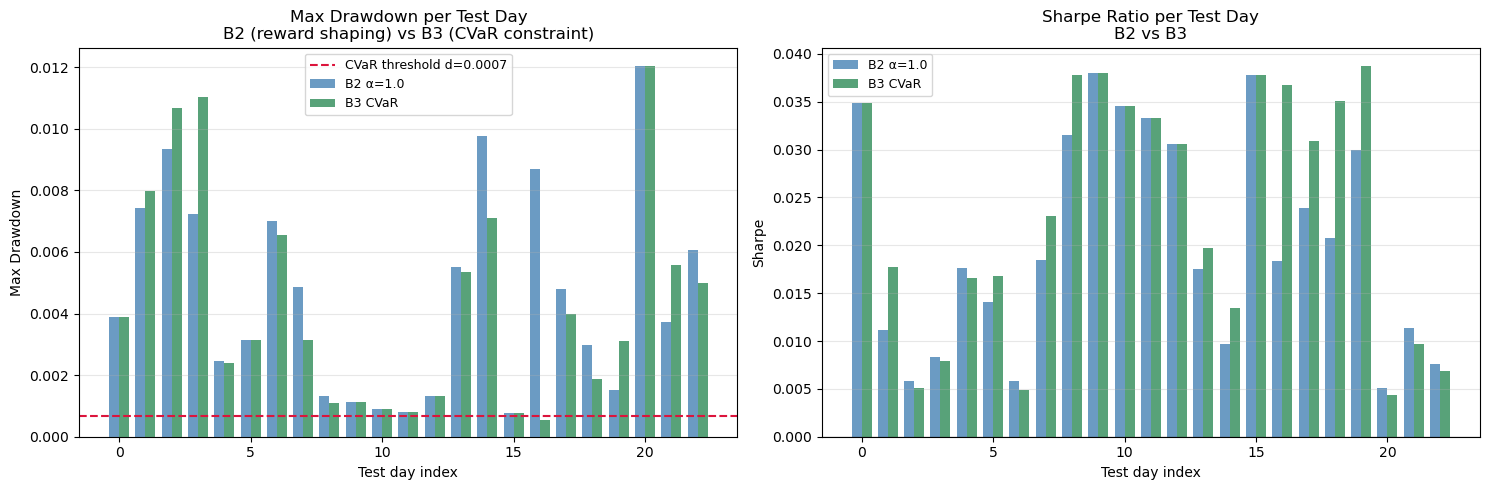


B3 achieves lower MaxDD on 10/23 test days.
B3 mean MaxDD = 0.0043  vs  B2 mean MaxDD = 0.0046


In [12]:
if b2_available:
    days = range(len(df_b3))
    x = np.arange(len(df_b3))
    width = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: MaxDD per day
    axes[0].bar(x - width/2, df_b2_best["Max DD"].values, width, label=f"B2 α={best_alpha}", color="steelblue", alpha=0.8)
    axes[0].bar(x + width/2, df_b3["Max DD"].values,      width, label="B3 CVaR",            color="seagreen",  alpha=0.8)
    axes[0].axhline(d, color="crimson", linestyle="--", label=f"CVaR threshold d={d:.4f}")
    axes[0].set_title("Max Drawdown per Test Day\nB2 (reward shaping) vs B3 (CVaR constraint)")
    axes[0].set_xlabel("Test day index")
    axes[0].set_ylabel("Max Drawdown")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3, axis="y")

    # Plot 2: Sharpe per day
    axes[1].bar(x - width/2, df_b2_best["Sharpe"].values, width, label=f"B2 α={best_alpha}", color="steelblue", alpha=0.8)
    axes[1].bar(x + width/2, df_b3["Sharpe"].values,      width, label="B3 CVaR",            color="seagreen",  alpha=0.8)
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_title("Sharpe Ratio per Test Day\nB2 vs B3")
    axes[1].set_xlabel("Test day index")
    axes[1].set_ylabel("Sharpe")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig(str(cfg.result_path("b2_vs_b3_comparison.png")), dpi=150, bbox_inches="tight")
    plt.show()

    b3_better_dd = (df_b3["Max DD"] < df_b2_best["Max DD"]).sum()
    print(f"\nB3 achieves lower MaxDD on {b3_better_dd}/{len(df_b3)} test days.")
    print(f"B3 mean MaxDD = {df_b3['Max DD'].mean():.4f}  vs  B2 mean MaxDD = {df_b2_best['Max DD'].mean():.4f}")